<a href="https://colab.research.google.com/github/aldo02032004/naufaldo.github.io/blob/main/daily_report_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Daily Report

One day's export, for either issue:

- **Politics**: a treemap of the day's top keywords, where the local LLM writes each tile's topic
  and headline, and a pie of author sentiment (one vote per author). `daily_overview()`.
- **Environment**: the environment map with issue and island bars. `env_daily()`.

### **Mounting Drive**

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


### **Inputing the Requirement**

In [56]:
import datetime as dt, os

TIMESTAMP       = dt.datetime.now().strftime('%d%m%Y')
ISSUES          = 'Politics' # 'Politics' or 'Environment'
ROBJ            = 'Bakom RI & Syahganda Nainggolan' # Changes this based on your research object
ROBJ_TERMS      = ['bakom', 'badan', 'komunikasi', 'pemerintah', 'pco', 'kepresidenan', 'syahganda', 'nainggolan'] # Politics: words naming ROBJ, left out of the treemap keywords
ZIP_SOURCE      = 'https://drive.google.com/file/d/1xp_Oawp4Krme4HtoFYj-cm2nm0Kg6i1l/view?usp=drive_link' # path zip di Drive, ATAU link share Drive (https://drive.google.com/...)
OUT_DIR         = f'/content/drive/MyDrive/model_result/daily_{ISSUES.lower()}_{TIMESTAMP}';os.makedirs(OUT_DIR,exist_ok=True) # To upload the result directly
N_TILES         = 6   # Politics: tiles in the treemap
N_POST          = 4    # Politics: representative posts per tile given to the LLM
MODEL_REPO      = 'faizonly5953/gemma2-9b-cpt-sahabatai-v1-instruct-GGUF' # Change the model based on the provider that you use
MODEL_FILE      = 'gemma2-9b-cpt-sahabatai-v1-instruct.q4_k_m.gguf' # Change the model based on the provider that you use

### **Notebook Set Up**

Politics also installs llama-cpp for the local LLM. A GPU whose driver supports CUDA 12 or newer
gets the CUDA build; anything else (CPU, or an older GPU) gets the CPU build, which is slower
but gives the same labels.

In [57]:
%pip install -q "great[all] @ git+https://github.com/azmkto/GREAT-Tools.git"

HAS_GPU = False
if ISSUES == 'Politics':
    import re, shutil, subprocess

    smi = subprocess.run(['nvidia-smi'], capture_output=True, text=True).stdout if shutil.which('nvidia-smi') else ''
    cuda = re.search(r'CUDA Version: (\d+)\.(\d+)', smi)
    major, minor = (int(cuda[1]), int(cuda[2])) if cuda else (0, 0)
    HAS_GPU = major >= 12
    CU_TAG = f'cu12{min(minor, 4) if major == 12 else 4}' if HAS_GPU else 'cpu'   # abetlen publishes cu121..cu124 + cpu
    print(f'Detected: CUDA {major}.{minor} -> {CU_TAG}' if cuda else f'Detected: no GPU -> {CU_TAG}')
    !pip install -q llama-cpp-python --extra-index-url https://abetlen.github.io/llama-cpp-python/whl/{CU_TAG}

    if HAS_GPU:
        # the cu12x wheel links CUDA 12 runtime libs; newer Colab images ship CUDA 13 only, so load the 12 libs first
        !pip install -q nvidia-cuda-runtime-cu12 nvidia-cublas-cu12
        import ctypes, glob, site
        for lib in ['libcudart.so.12', 'libcublasLt.so.12', 'libcublas.so.12']:
            ctypes.CDLL(glob.glob(f'{site.getsitepackages()[0]}/nvidia/*/lib/{lib}')[0], mode=ctypes.RTLD_GLOBAL)

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Detected: CUDA 13.0 -> cu124


In [58]:
import json

import pandas as pd
from tqdm.auto import tqdm

from great import classify_issue, resolve_frame
from great.viz import checks, prep
from great.viz.environment import env_daily
from great.viz.overview import author_sentiment, daily_overview, keyword_tiles, representative_posts

### **Accessing File**

In [59]:
import zipfile

zip_path = ZIP_SOURCE
if ZIP_SOURCE.startswith('http'):
    import gdown
    zip_path = gdown.download(ZIP_SOURCE, '/content/input.zip', fuzzy=True, quiet=True)

with zipfile.ZipFile(zip_path) as z:
    # ambil semua excel di dalam zip, skip file sampah bawaan mac/excel
    names = [n for n in z.namelist()
             if n.lower().endswith(('.xlsx', '.xls'))
             and not n.startswith('__MACOSX')
             and not os.path.basename(n).startswith('~$')]
    df = pd.concat([pd.read_excel(z.open(n), header=1) for n in names], ignore_index=True)

print(f'{len(names)} file excel: {names}')

df1, start_date, end_date = prep.prepare_data(df)

print(f'{start_date} - {end_date}')

1 file excel: ['report_16834_all_all_20261008_20261008_2877_Prabowo.xlsx']
08 Oct 2026 - 08 Oct 2026


### **Checking Dataframe Info**

In [60]:
checks.frame_info(df1, 'Main Dataframe')
checks.composition(df1)


Main Dataframe Info:

Number of Rows: 7,008
Columns: ['No', 'Type', 'Headline', 'Mentions', 'Date', 'Link', 'Media', 'Sentiment', 'Author', 'Followers', 'Retweeted', 'Favourited', 'Location']

Data Types:
No                     int64
Type                  object
Headline              object
Mentions              object
Date          datetime64[ns]
Link                  object
Media                 object
Sentiment             object
Author                object
Followers              int64
Retweeted              int64
Favourited             int64
Location              object 

Sentiment Breakdown:
           Count  Share (%)
Sentiment                  
positive    3714       53.0
negative    2527       36.1
neutral      767       10.9 

Platform Breakdown:
           Count  Share (%)
Media                      
Twitter     3483       49.7
News        3201       45.7
Youtube      168        2.4
Instagram     95        1.4
Tiktok        32        0.5
Facebook      23        0.3
Threads 

### **Topic and Headline from the LLM**

Politics only. `keyword_tiles()` files each post under its most distinctive keyword and keeps the
`N_TILES` biggest. For each tile the LLM reads the keyword and its `N_DOCS` most repeated
headlines (`representative_posts()`), and writes the tile's topic and headline. If a call
fails, the tile keeps the keyword as its topic and its top headline, cut to 15 words.

In [51]:
if ISSUES == 'Politics':
    from huggingface_hub import hf_hub_download
    from llama_cpp import Llama

    model_path = hf_hub_download(repo_id=MODEL_REPO, filename=MODEL_FILE)
    llm = Llama(model_path=model_path, n_gpu_layers=-1 if HAS_GPU else 0, n_ctx=4096, n_batch=512, verbose=False)

llama_kv_cache_iswa: using full-size SWA cache (ref: https://github.com/ggml-org/llama.cpp/pull/13194#issuecomment-2868343055)


In [52]:
FIELDS = ['topic', 'headline']
SCHEMA = {'type': 'object', 'properties': {f: {'type': 'string'} for f in FIELDS}, 'required': FIELDS}

PROMPT = """You are a media analyst at a socio-political think tank, summarising today's public discourse.

These posts all use the keyword "{keyword}":
{documents}

Return JSON with exactly these fields:
1. topic    - the topic in at most 3 words: the person, institution, or issue the posts are about.
2. headline - one news-style headline of at most 7 words saying what happened, grounded in the posts.

Answer in Indonesian. Output only JSON.
"""

if ISSUES == 'Politics':
    df1['Keyword'] = keyword_tiles(df1, exclude=ROBJ_TERMS, n_tiles=N_TILES)

    records = []
    for keyword, count in tqdm(df1['Keyword'].value_counts().items(), total=N_TILES, desc='tiles'):
        docs = representative_posts(df1[df1['Keyword'] == keyword], n=N_DOCS)
        try:
            r = llm.create_chat_completion(
                messages=[{'role': 'user', 'content': PROMPT.format(keyword=keyword, documents='\n'.join(f'- {d}' for d in docs))}],
                response_format={'type': 'json_object', 'schema': SCHEMA},
                temperature=0.2, max_tokens=200,
            )
            out = json.loads(r['choices'][0]['message']['content'])
        except Exception as e:
            print(f'{keyword} failed: {type(e).__name__}: {e}')
            out = {}
        records.append({
            'Keyword': keyword,
            'Count': count,
            'Topic': (out.get('topic') or keyword).strip(),
            'Headline': (out.get('headline') or ' '.join(docs[0].split()[:15])).strip(),
        })

    tiles = pd.DataFrame(records)
    tiles.to_excel(f'{OUT_DIR}/daily_politics_topics_{TIMESTAMP}.xlsx', index=False)
    display(tiles)

tiles:   0%|          | 0/6 [00:00<?, ?it/s]

,Keyword,Count,Topic,Headline
0,sma,915,Gibran Rakabuming,Transkrip SMA Gibran Jadi Perdebatan
1,tni,714,TNI,Prabowo Taklimat 800 Pati TNI-Polri
2,gibran,594,Gibran Rakabuming,Gibran Jadi Alasan Pilih Prabowo
3,rakyat,448,Prabowo,Prabowo dikritik atas kebijakannya
4,menteri,373,Gibran Rakabuming,Menteri Larang Bertemu Gibran
5,hilirisasi,340,Prabowo Hilirisasi,Prabowo Luncurkan Proyek Hilirisasi Rp180 T


### **Visualize**

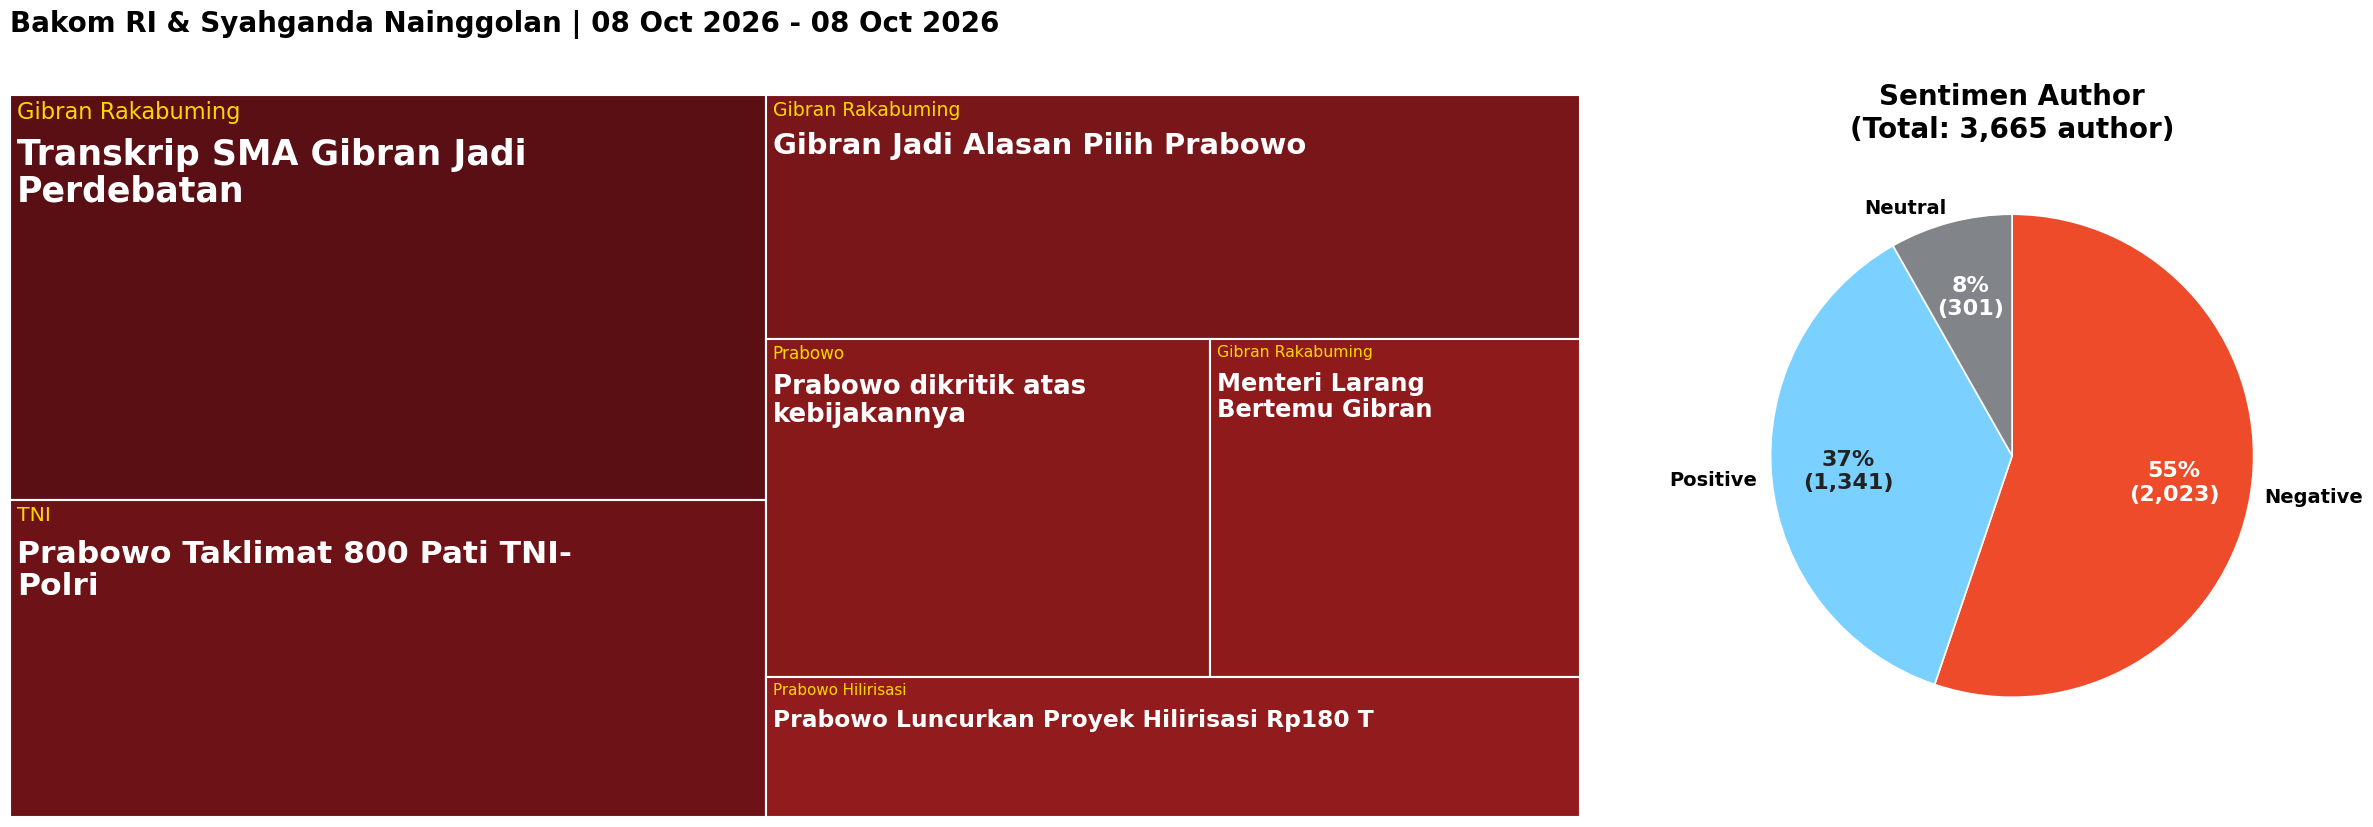

In [53]:
if ISSUES == 'Politics':
    fig = daily_overview(tiles, author_sentiment(df1), ROBJ, start_date, end_date)
else:
    df1['Isu_Inti'] = df1['Mentions'].map(classify_issue)
    df1[['Provinsi', 'Pulau']] = resolve_frame(df1)
    fig = env_daily(df1, start_date=start_date, end_date=end_date)

fig.savefig(f'{OUT_DIR}/daily_{ISSUES.lower()}_{TIMESTAMP}.png', dpi=150, bbox_inches='tight')

In [54]:
from tqdm.auto import tqdm

JUNK_TITLES = r'(?:#\w+.*){3}|Halaman \d+|Anda mencari|^Berita .* Terkini'   # titles to skip: hashtag-only posts, tag/search pages

SUMMARY_FIELDS = ['summary']
SUMMARY_SCHEMA = {'type': 'object', 'properties': {f: {'type': 'string'} for f in SUMMARY_FIELDS}, 'required': SUMMARY_FIELDS}

SUMMARY_PROMPT = """You are a media analyst at a socio-political think tank, summarising today's public discourse.

This is one post from today's coverage:
Title: {title}
Content: {content}

Return JSON with exactly this field:
1. summary - a summary of at most 20 words saying what happened, using only facts stated in the post. Do not add details.

Answer in Indonesian. Output only JSON.
"""

STORY = 'Keyword' if 'Keyword' in df1 else 'Headline'   # Politics: one post per tile, so one story doesn't fill every slot

records = []
for sentiment in ['positive', 'negative']:
    top = (df1[(df1['Sentiment'] == sentiment) & ~df1['Headline'].str.contains(JUNK_TITLES, case=False, na=True)]
           .groupby('Headline')
           .agg(Count=('Author', 'nunique'), Reach=('Followers', 'max'), Media=('Media', 'first'),
                Link=('Link', 'first'), Content=('Mentions', 'first'), Story=(STORY, 'first'))
           .reset_index()
           .sort_values(['Count', 'Reach'], ascending=False))
    top['Story'] = top['Story'].fillna(top['Headline'])   # posts outside the tiles count as their own story
    top = top.drop_duplicates('Story').head(N_POSTS)

    for post in tqdm(top.itertuples(), total=len(top), desc=sentiment):
        out = {}
        if ISSUES == 'Politics':
            try:
                r = llm.create_chat_completion(
                    messages=[{'role': 'user', 'content': SUMMARY_PROMPT.format(title=post.Headline, content=str(post.Content)[:1500])}],
                    response_format={'type': 'json_object', 'schema': SUMMARY_SCHEMA},
                    temperature=0.2, max_tokens=200,
                )
                out = json.loads(r['choices'][0]['message']['content'])
            except Exception as e:
                print(f'{post.Headline[:40]} failed: {type(e).__name__}: {e}')
        records.append({
            'Sentiment': sentiment,
            'Media': post.Media,
            'Story': post.Story,
            'Headline': post.Headline,
            'Summary': (out.get('summary') or ' '.join(post.Headline.split()[:20])).strip(),
            'Link': post.Link,
            'Count': post.Count,
        })

top_posts = pd.DataFrame(records)
top_posts.to_excel(f'{OUT_DIR}/daily_{ISSUES.lower()}_top_posts_{TIMESTAMP}.xlsx', index=False)
pd.set_option('display.max_colwidth', None)
display(top_posts.style.format({'Link': lambda u: f'<a href="{u}" target="_blank">link</a>'}))

positive:   0%|          | 0/6 [00:00<?, ?it/s]

negative:   0%|          | 0/6 [00:00<?, ?it/s]

,Sentiment,Media,Story,Headline,Summary,Link,Count
0,positive,News,hilirisasi,Prabowo tiba di IWIP Halmahera Tengah luncurkan proyek hilirisasi,"Prabowo meluncurkan program hilirisasi di IWIP Halmahera Tengah, Maluku Utara.",link,5
1,positive,News,tni,Menhan Sjafrie nilai taklimat Prabowo perkuat soliditas TNI-Polri,Menhan Sjafrie Sjamsoeddin menilai taklimat Presiden Prabowo memperkuat soliditas TNI-Polri.,link,4
2,positive,News,menteri,Abuleke Bahlil,"Bahlil Lahadalia, Menko Hilirisasi dan Transisi Energi, menjelaskan arti kata",link,3
3,positive,News,"APBN 2027 Rp4.097 Triliun, Mampukah Ekonomi RI Tumbuh 6 Persen? : Economy","APBN 2027 Rp4.097 Triliun, Mampukah Ekonomi RI Tumbuh 6 Persen? : Economy",Menteri Keuangan Suahasil Nazara mengatakan APBN 2027 sebesar Rp4.097 triliun untuk mendukung prioritas pemerintahan Presiden Prabowo Subianto dan Wakil Presiden Gibran Rakabuming Raka.,link,2
4,positive,News,"Dua tahun Prabowo-Gibran, Menperin bidik kontribusi manufaktur RI naik","Dua tahun Prabowo-Gibran, Menperin bidik kontribusi manufaktur RI naik",Menperin ingin kontribusi industri manufaktur terhadap PDB naik dari 19% menjadi lebih dari 20% hingga 25%.,link,2
5,positive,News,gibran,"Jokowi Temui Prabowo saat Sidang Putusan Gibran, Ajudan Ungkap Isi Pertemuan",Jokowi bertemu Prabowo di kediaman Prabowo di Jakarta Selatan.,link,2
6,negative,News,"Tak hanya putus akses, Pemerintah tegas perangi judol menyeluruh","Tak hanya putus akses, Pemerintah tegas perangi judol menyeluruh",Pemerintah telah menangani 2.087.109 konten perjudian online sejak awal 2025.,link,2
7,negative,Youtube,gibran,"AKHIRNYA BOCOR PERTEMUAN JOKOWI DAN PRABOWO, 2 JAM SBLM PUTUSAN MK IJASAH GIBRAN?",Terungkap pertemuan Jokowi dan Prabowo 2 jam sebelum putusan MK terkait ijazah Gibran.,link,1
8,negative,Youtube,tni,BONGKAR KONDISI BANGSA! Alasan Prabowo Mendadak Kumpulkan 800 Jenderal TNI-Polri di Istana 🚨,"Presiden Prabowo Subianto mengumpulkan 800 Jenderal TNI-Polri untuk membahas tantangan dan perkembangan kondisi bangsa, termasuk ancaman modern dan pelanggaran di masa lalu.",link,1
9,negative,News,hilirisasi,"Baterai EV hingga Komponen Alat Berat, 4 Produk Hilirisasi IWIP Mulai Ekspor","Empat produk hasil hilirisasi di IWIP, Maluku Utara, mulai diekspor, termasuk baterai kendaraan listrik.",link,1
